# ARI 410/510 Lab 2 Starter Notebook

This notebook only gets the data loaded for you: it downloads and unzips the dataset, reads the provided train and test files, and attaches the activity names and feature names. Everything after that is the lab.

**How to use this:** In Colab, *File → Save a copy in Drive*, then run top to bottom.

## 0. Get the data

Either download it directly (next cell), or download the zip from Canvas and upload it to Colab's file panel (left sidebar), then set `ZIP_PATH` to its name.

Note: the download is a zip *inside* a zip. The helper below handles that for you.

In [91]:
import os, zipfile, glob, urllib.request

ZIP_PATH = "har.zip"   # change this if you uploaded the file under a different name
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"

if not os.path.exists(ZIP_PATH):
    try:
        print("Downloading from UCI...")
        urllib.request.urlretrieve(URL, ZIP_PATH)
    except Exception as e:
        print("Download failed:", e, "\nUpload the zip from Canvas instead and set ZIP_PATH.")

# Unzip the outer zip, then the inner 'UCI HAR Dataset.zip'
with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall("har_raw")
inner = glob.glob("har_raw/**/UCI HAR Dataset.zip", recursive=True)
if inner:
    with zipfile.ZipFile(inner[0]) as z:
        z.extractall("har_raw")
DATA = glob.glob("har_raw/**/UCI HAR Dataset", recursive=True)[0].rsplit("/train", 1)[0] + '\\'
print("Data folder:", DATA)

Data folder: har_raw\UCI HAR Dataset\


## 1. Load the data

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Feature names. Some names appear more than once in features.txt, so we add
# a numeric suffix to duplicates to keep every name unique.
raw_names = pd.read_csv(DATA + "features.txt", sep=r"\s+", header=None)[1].tolist()
seen, feature_names = {}, []
for n in raw_names:
    seen[n] = seen.get(n, 0) + 1
    feature_names.append(n if seen[n] == 1 else f"{n}__{seen[n]}")

# Map integer labels (1-6) to activity names
label_map = dict(pd.read_csv(DATA + "activity_labels.txt", sep=r"\s+", header=None).values)

def load(split):
    X = pd.read_csv(DATA + f"{split}/X_{split}.txt", sep=r"\s+", header=None).values
    y = pd.read_csv(DATA + f"{split}/y_{split}.txt", header=None)[0].map(label_map).values
    return X, y

X_train_full, y_train_full = load("train")
X_test, y_test = load("test")
print("train:", X_train_full.shape, " test:", X_test.shape)
print("activities:", sorted(set(y_train_full)))

train: (7352, 561)  test: (2947, 561)
activities: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


## Plotting helpers

Making plots isn't the point of this lab, so here are three general-purpose helpers. They're demonstrated below on **made-up toy data**; you'll call them with your own results. Feel free to modify them or write your own.

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_bar(labels, title="", xlabel="", ylabel="count"):
    """Bar chart of how often each value in `labels` occurs."""
    counts = pd.Series(labels).value_counts()
    fig, ax = plt.subplots(figsize=(7, 3.5))
    counts.plot(kind="bar", ax=ax)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

def plot_lines(x, series, title="", xlabel="", ylabel="", hline=None, hline_label=None, logx=False):
    """Line plot of one or more series against x.
    `series` is a dict {line name: list of y values (same length as x)}.
    Optionally draws a dashed horizontal reference line at y = hline."""
    fig, ax = plt.subplots(figsize=(7, 4))
    for name, ys in series.items():
        ax.plot(x, ys, marker="o", label=name)
    if hline is not None:
        ax.axhline(hline, linestyle="--", color="gray", label=hline_label)
    if logx:
        ax.set_xscale("log")
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    if len(series) > 1 or hline_label:
        ax.legend()
    plt.tight_layout(); plt.show()

def scatter_2d(Z, labels, title="", xlabel="", ylabel=""):
    """Scatter plot of the first two columns of Z, one color per value in `labels`."""
    Z, labels = np.asarray(Z), np.asarray(labels)
    fig, ax = plt.subplots(figsize=(7, 5))
    for lab in sorted(set(labels), key=str):
        m = labels == lab
        ax.scatter(Z[m, 0], Z[m, 1], s=5, alpha=0.5, label=str(lab))
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(markerscale=3, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()

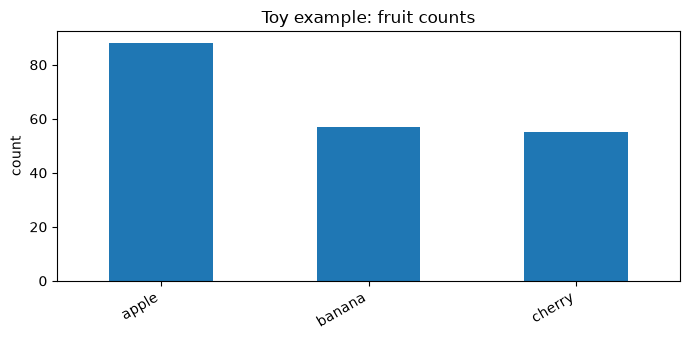

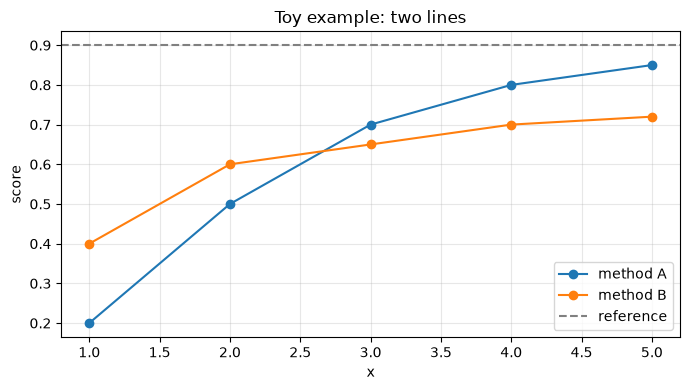

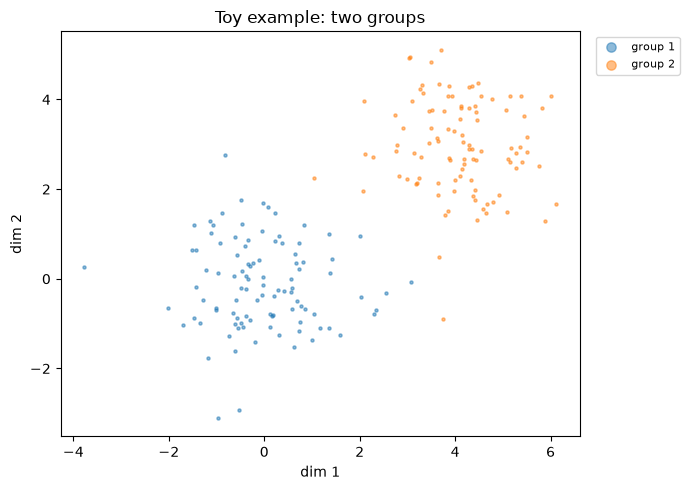

In [94]:
# ---- Demo on made-up toy data. Replace with your own data and results. ----
rng = np.random.default_rng(0)

# plot_bar: pass a list/array of category labels
# create random data
toy_labels = rng.choice(["apple", "banana", "cherry"], size=200, p=[0.5, 0.3, 0.2])
# plot it
plot_bar(toy_labels, title="Toy example: fruit counts")

# plot_lines: x values plus a dict of named y-value lists
toy_x = [1, 2, 3, 4, 5]
plot_lines(toy_x, {"method A": [0.2, 0.5, 0.7, 0.8, 0.85],
                   "method B": [0.4, 0.6, 0.65, 0.7, 0.72]},
           title="Toy example: two lines", xlabel="x", ylabel="score",
           hline=0.9, hline_label="reference")

# scatter_2d: an (n, 2+) array plus one label per row
toy_points = np.vstack([rng.normal([0, 0], 1, (100, 2)), rng.normal([4, 3], 1, (100, 2))])
toy_groups = ["group 1"] * 100 + ["group 2"] * 100
scatter_2d(toy_points, toy_groups, title="Toy example: two groups", xlabel="dim 1", ylabel="dim 2")

## You take it from here

You now have `X_train_full`, `y_train_full` (the provided training set), `X_test`, `y_test`, (the held-out test set) and `feature_names`. The assignment PDF describes what the lab needs to cover. How you organize your code and your notebook is up to you; add as many cells as you like, or don't use this starter notebook at all if you don't want to.

In [95]:
X_train_full.shape

(7352, 561)

In [96]:
#Split the data 80/10/10
from sklearn.model_selection import train_test_split

X_train, X_dev, y_train, y_dev = train_test_split(X_train_full, y_train_full, test_size=.1)

In [97]:
X_train.shape

(6616, 561)

In [98]:
# apply standard scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)


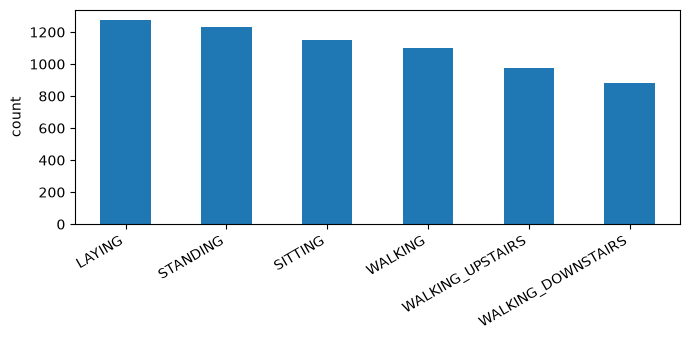

In [99]:
plot_bar(y_train)

In [100]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)

In [101]:
X_train_scaled.shape

(6616, 561)

In [102]:
X_train_scaled_pca = pca.fit_transform(X_train_scaled)

In [103]:
X_train_scaled_pca.shape

(6616, 100)

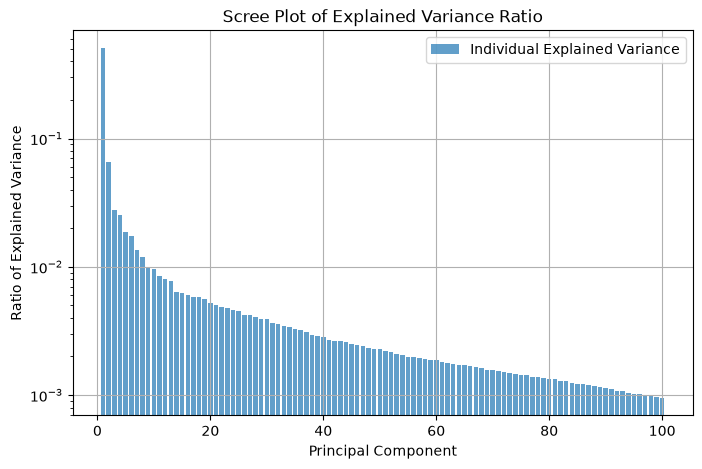

In [104]:
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, label='Individual Explained Variance',log='y')

plt.xlabel('Principal Component')
plt.ylabel('Ratio of Explained Variance')
plt.title('Scree Plot of Explained Variance Ratio')
plt.legend()
plt.grid(True)
plt.show()

In [105]:
X_dev_scaled_pca = pca.transform(X_dev_scaled)
X_test_scaled_pca = pca.transform(X_test_scaled)

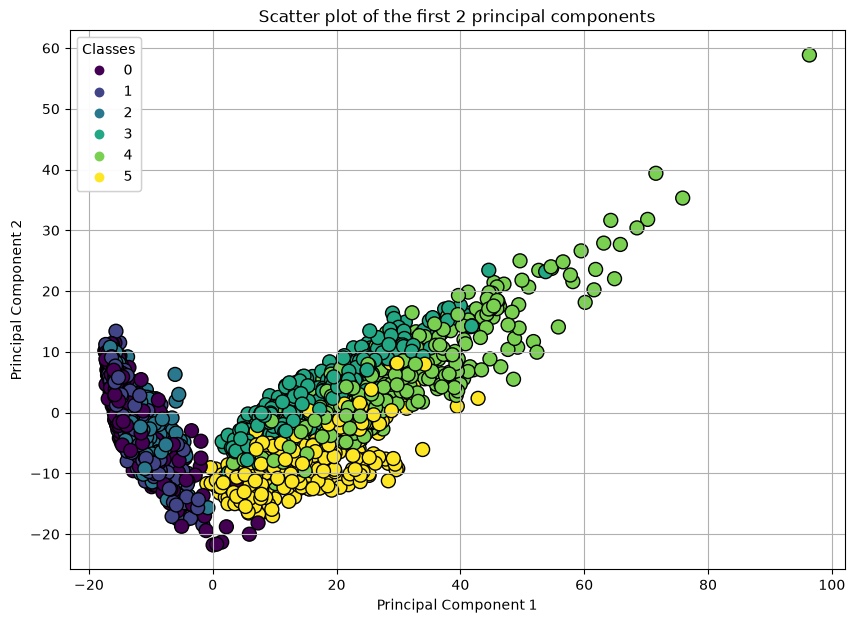

In [106]:
plt.figure(figsize=(10, 7))

y_train_encoded = pd.Categorical(y_train)

# Scatter plot
scatter = plt.scatter(X_train_scaled_pca[:, 0], X_train_scaled_pca[:, 1], c=y_train_encoded.codes, cmap='viridis', edgecolor='k', s=100)

# Create a legend
legend1 = plt.legend(*scatter.legend_elements(), title="Classes")
plt.gca().add_artist(legend1)

plt.title("Scatter plot of the first 2 principal components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

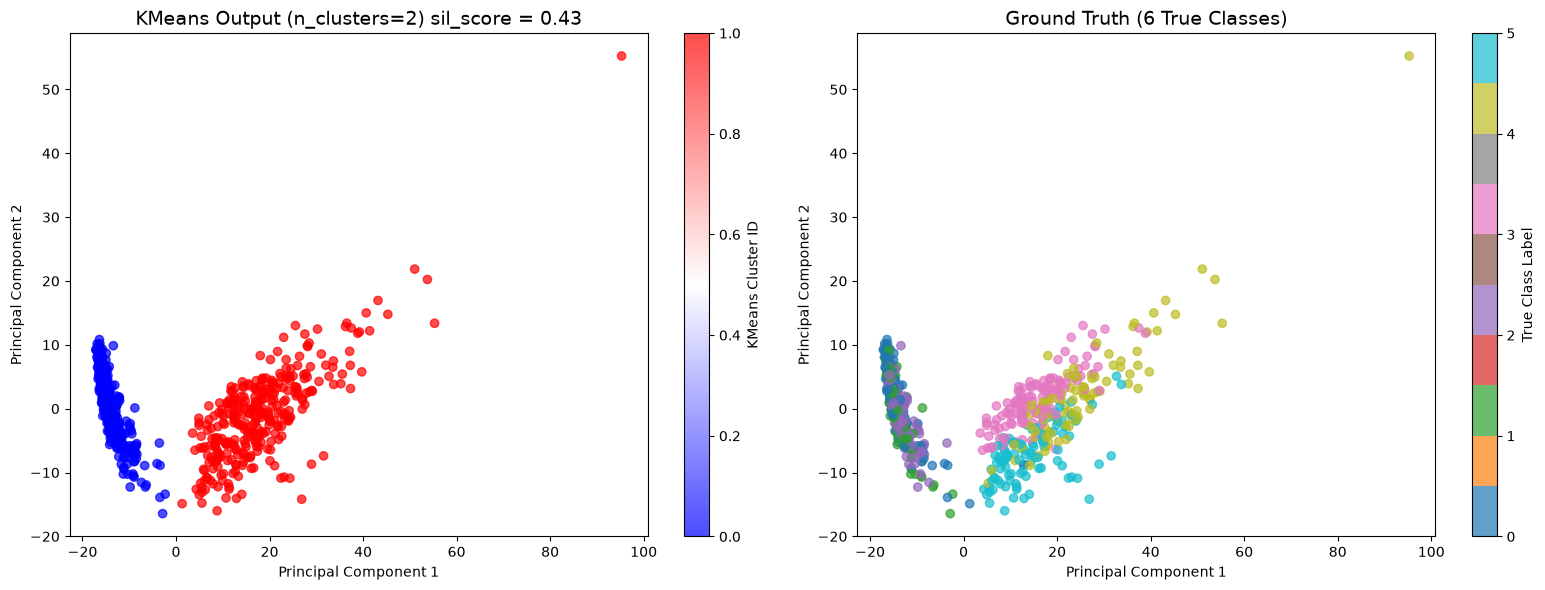

<Figure size 640x480 with 0 Axes>

In [107]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

kmeans2 = KMeans(n_clusters = 2)

kmeans2.fit(X_train_scaled_pca)

X_dev_pred = kmeans2.predict(X_dev_scaled_pca)

sil_score = silhouette_score(X_dev_scaled_pca, X_dev_pred)

# Create a figure with 2 plots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: The 2 Unsupervised KMeans Clusters
scatter1 = ax1.scatter(
    X_dev_scaled_pca[:, 0], 
    X_dev_scaled_pca[:, 1], 
    c=X_dev_pred, 
    cmap='bwr',       # Clean Blue/Red colormap for 2 clusters
    alpha=0.7
)
ax1.set_title(f'KMeans Output (n_clusters=2) sil_score = {sil_score:.2f}', fontsize=14)
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
fig.colorbar(scatter1, ax=ax1, label='KMeans Cluster ID')

y_dev_encoded = pd.Categorical(y_dev)

# Plot 2: The 6 Original True Classes
scatter2 = ax2.scatter(
    X_dev_scaled_pca[:, 0], 
    X_dev_scaled_pca[:, 1], 
    c=y_dev_encoded.codes,          # Your original 6 classes
    cmap='tab10',     # Categorical colormap great for up to 10 classes
    alpha=0.7
)
ax2.set_title('Ground Truth (6 True Classes)', fontsize=14)
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
fig.colorbar(scatter2, ax=ax2, label='True Class Label')

plt.tight_layout()
plt.show()
plt.savefig("plots/k=2")

In [108]:
def km(numk = 2):
    kmeans = KMeans(n_clusters = numk)

    kmeans.fit(X_train_scaled_pca)

    X_dev_pred = kmeans.predict(X_dev_scaled_pca)

    sil_score = silhouette_score(X_dev_scaled_pca, X_dev_pred)

    # Create a figure with 2 plots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: The 2 Unsupervised KMeans Clusters
    scatter1 = ax1.scatter(
        X_dev_scaled_pca[:, 0], 
        X_dev_scaled_pca[:, 1], 
        c=X_dev_pred, 
        cmap='tab10',       # Clean Blue/Red colormap for 2 clusters
        alpha=0.7
    )
    ax1.set_title(f'KMeans Output (n_clusters={numk}) sil_score = {sil_score:.2f}', fontsize=14)
    ax1.set_xlabel('Principal Component 1')
    ax1.set_ylabel('Principal Component 2')
    fig.colorbar(scatter1, ax=ax1, label='KMeans Cluster ID')

    y_dev_encoded = pd.Categorical(y_dev)

    # Plot 2: The 6 Original True Classes
    scatter2 = ax2.scatter(
        X_dev_scaled_pca[:, 0], 
        X_dev_scaled_pca[:, 1], 
        c=y_dev_encoded.codes,          # Your original 6 classes
        cmap='tab10',     # Categorical colormap great for up to 10 classes
        alpha=0.7
    )
    ax2.set_title('Ground Truth (6 True Classes)', fontsize=14)
    ax2.set_xlabel('Principal Component 1')
    ax2.set_ylabel('Principal Component 2')
    fig.colorbar(scatter2, ax=ax2, label='True Class Label')

    plt.tight_layout()
    plt.savefig(f"plots/k={numk}")
    plt.show()

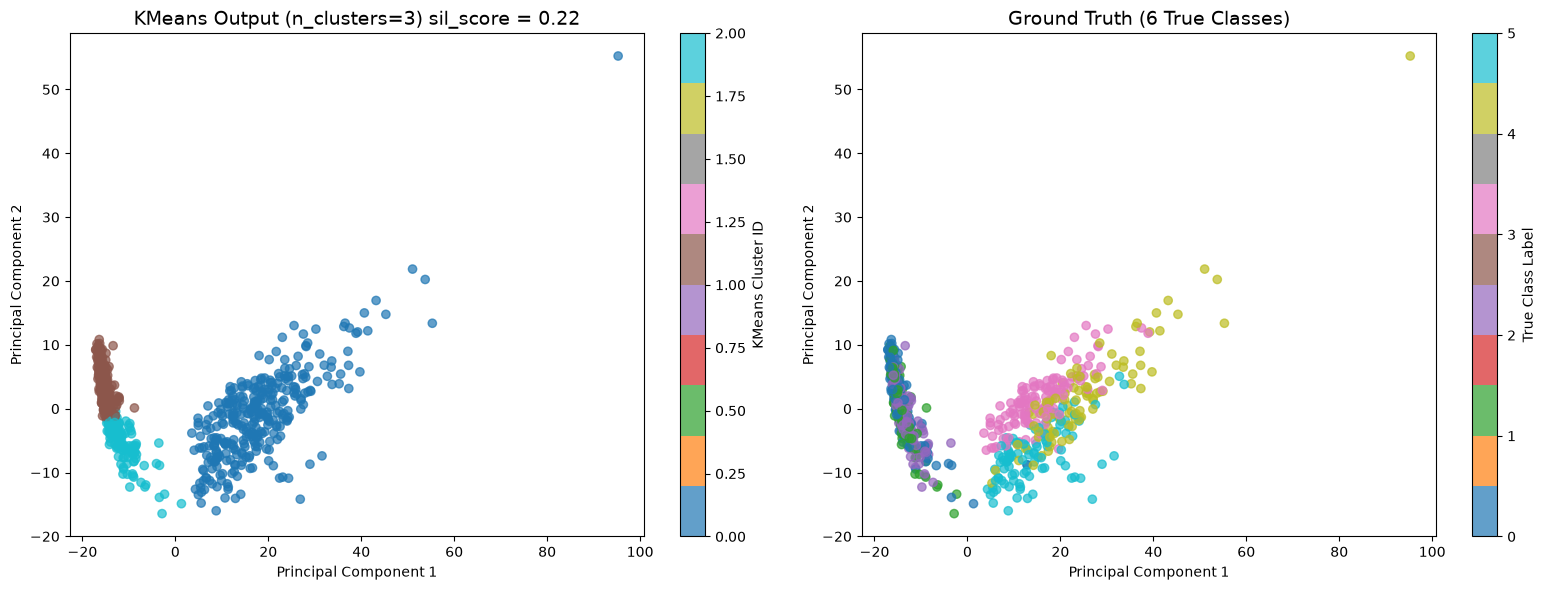

In [109]:
km(3)

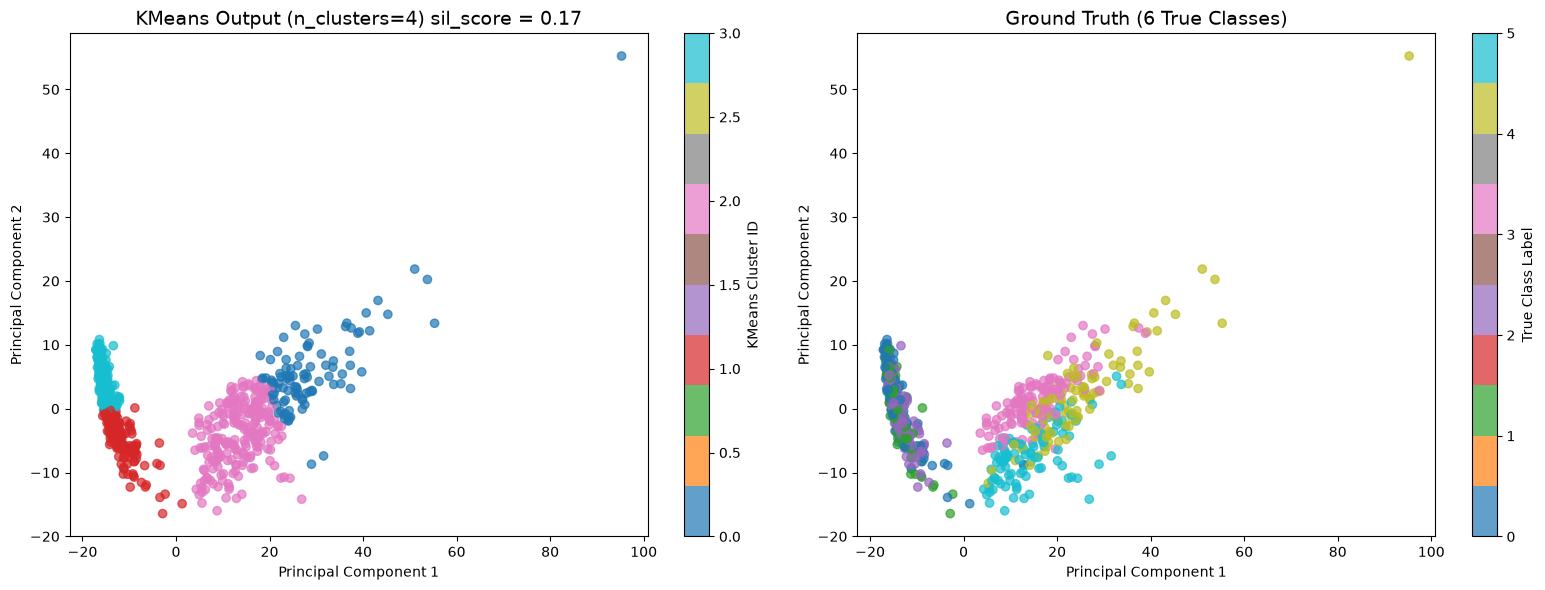

In [110]:
km(4)

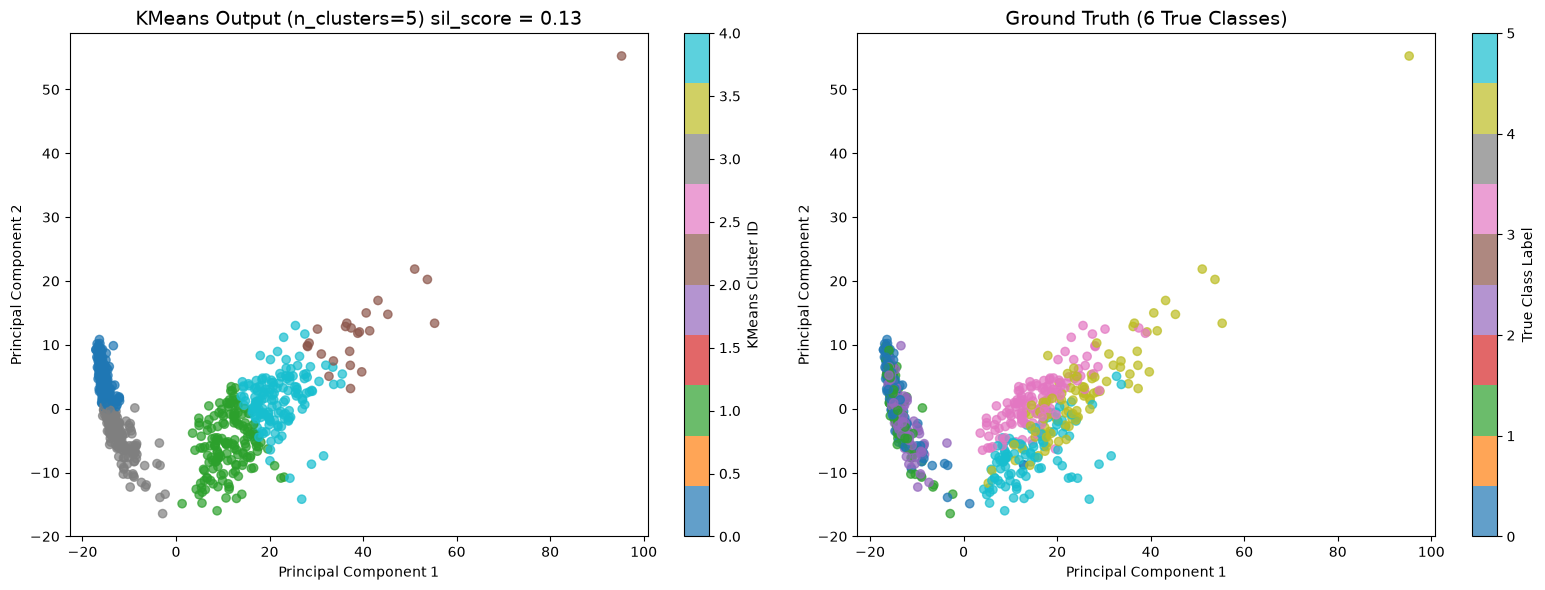

In [111]:
km(5)

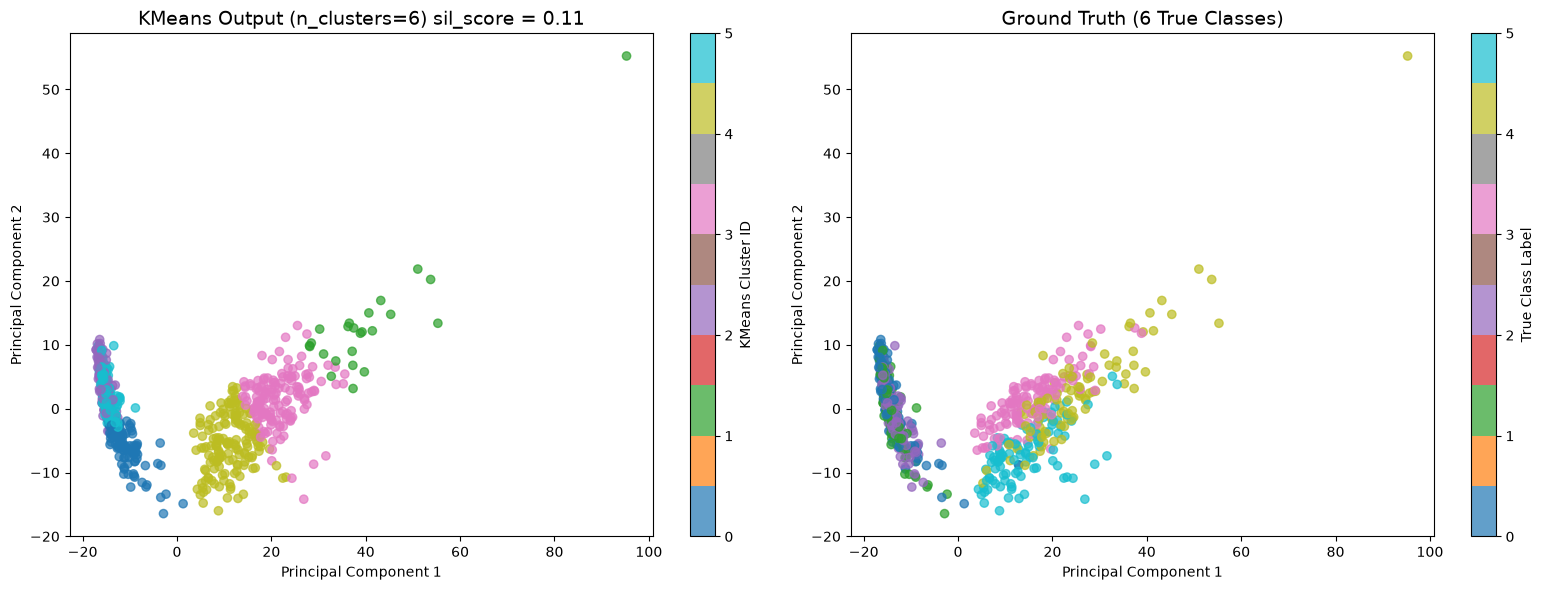

In [112]:
km(6)

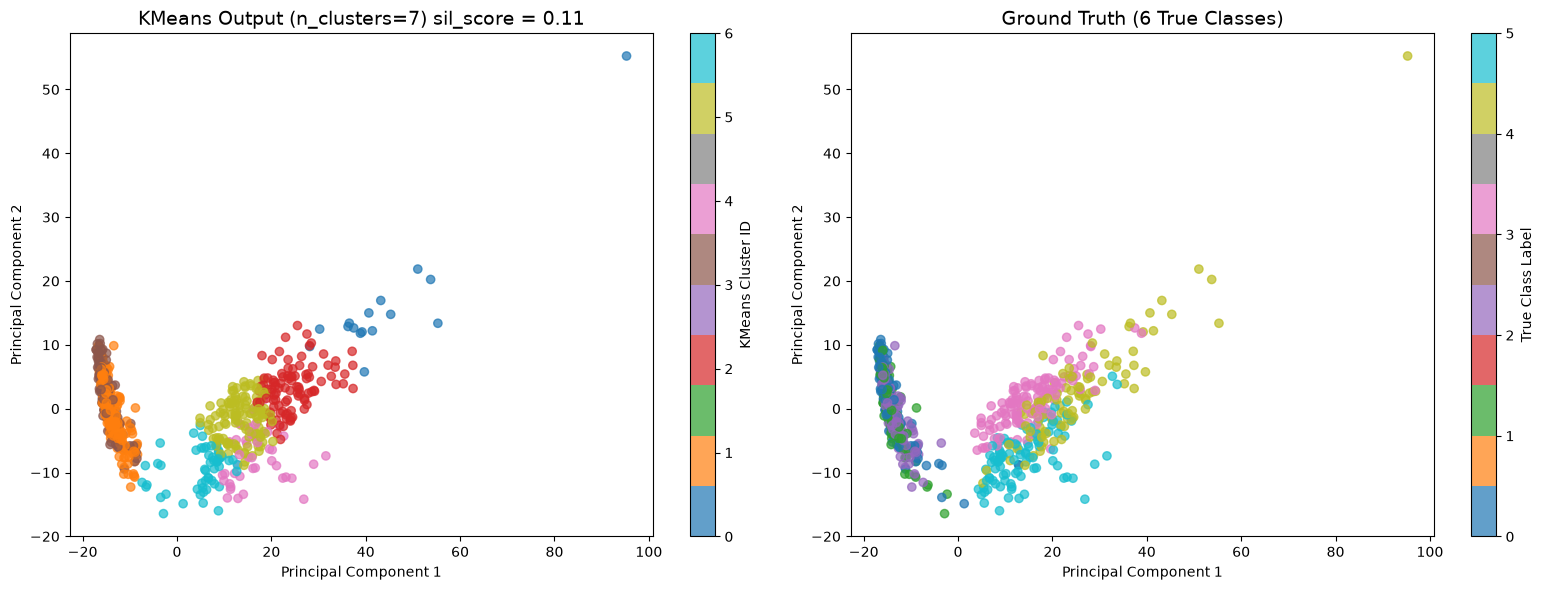

In [113]:
km(7)

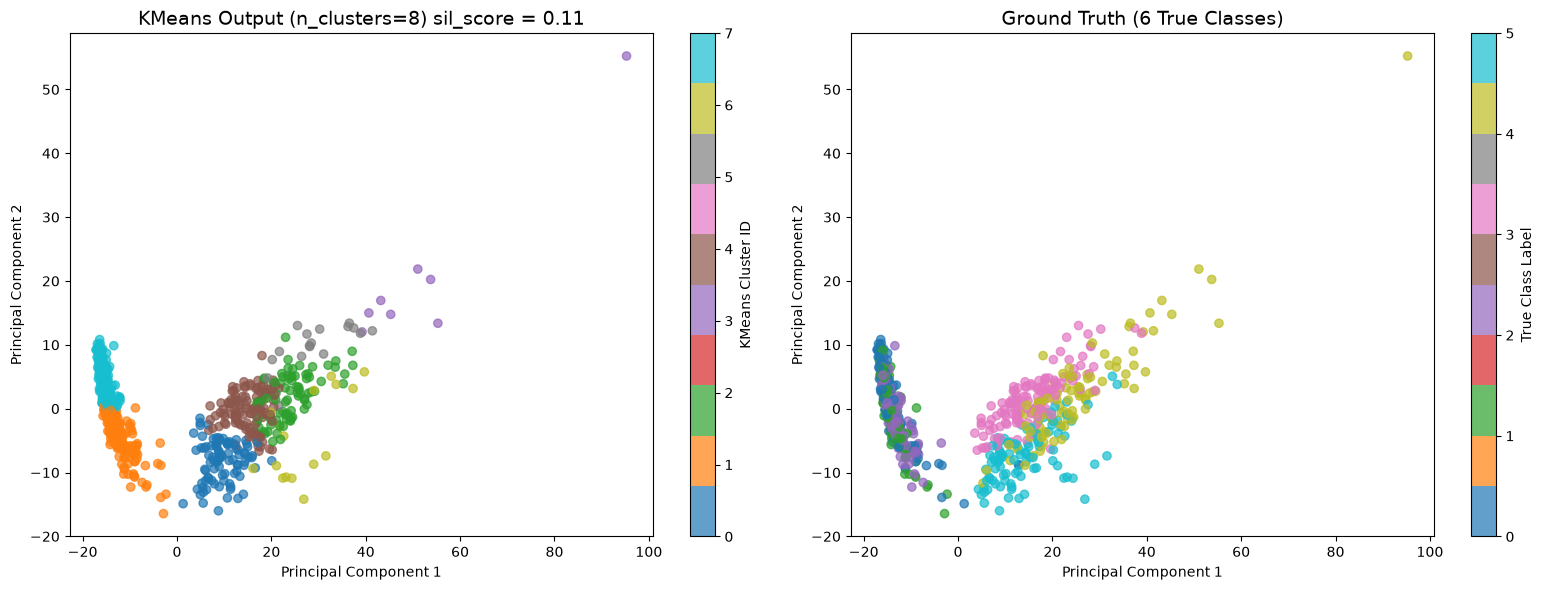

In [114]:
km(8)

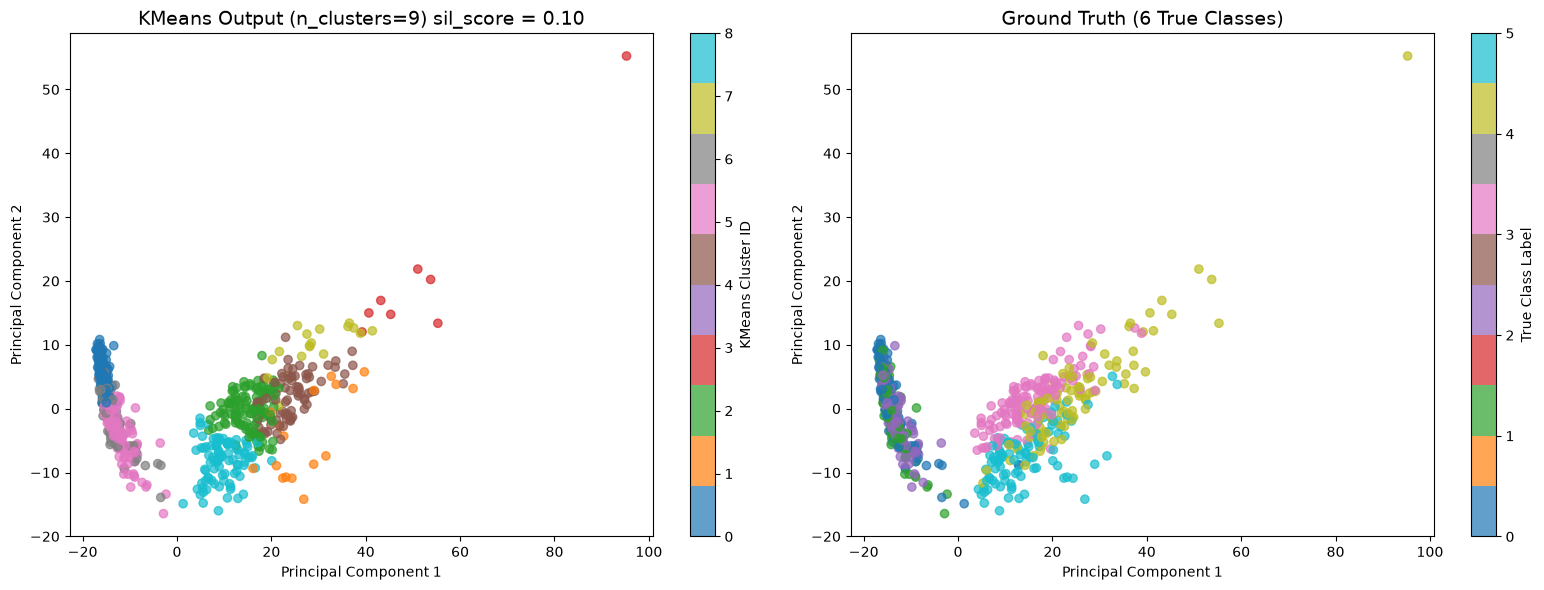

In [115]:
km(9)

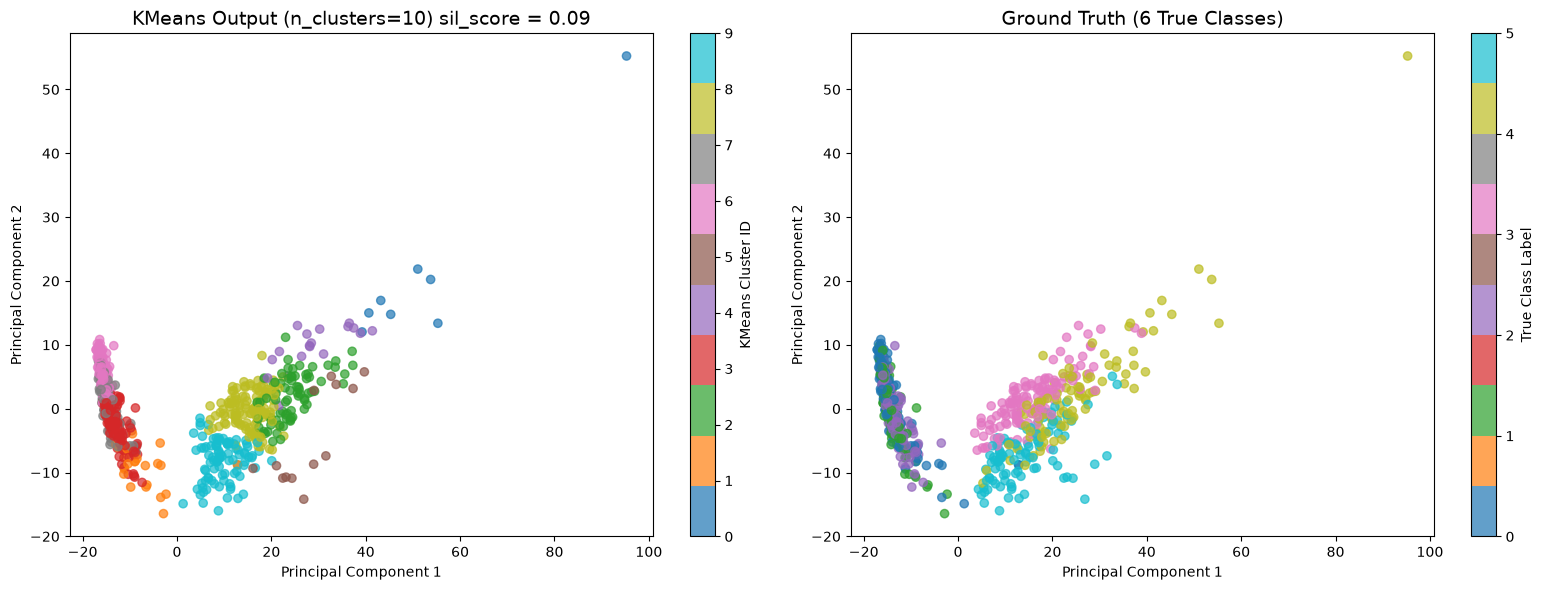

In [116]:
km(10)

In [117]:
from sklearn.cluster import DBSCAN

In [120]:
def db(n = .1):
    db = DBSCAN(eps = n)

    X_dev_pred = db.fit_predict(X_dev_scaled_pca)

    sil_score = silhouette_score(X_dev_scaled_pca, X_dev_pred)

    # Create a figure with 2 plots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: The 2 Unsupervised KMeans Clusters
    scatter1 = ax1.scatter(
        X_dev_scaled_pca[:, 0], 
        X_dev_scaled_pca[:, 1], 
        c=X_dev_pred, 
        cmap='tab10',       # Clean Blue/Red colormap for 2 clusters
        alpha=0.7
    )
    ax1.set_title(f'DBSCAN Output (eps={n}) sil score = {sil_score:.2f}', fontsize=14)
    ax1.set_xlabel('Principal Component 1')
    ax1.set_ylabel('Principal Component 2')
    fig.colorbar(scatter1, ax=ax1, label='DBSCAN Cluster ID')

    y_dev_encoded = pd.Categorical(y_dev)

    # Plot 2: The 6 Original True Classes
    scatter2 = ax2.scatter(
        X_dev_scaled_pca[:, 0], 
        X_dev_scaled_pca[:, 1], 
        c=y_dev_encoded.codes,          # Your original 6 classes
        cmap='tab10',     # Categorical colormap great for up to 10 classes
        alpha=0.7
    )
    ax2.set_title('Ground Truth (6 True Classes)', fontsize=14)
    ax2.set_xlabel('Principal Component 1')
    ax2.set_ylabel('Principal Component 2')
    fig.colorbar(scatter2, ax=ax2, label='True Class Label')

    plt.tight_layout()
    plt.savefig(f"plots/dbscan")
    plt.show()

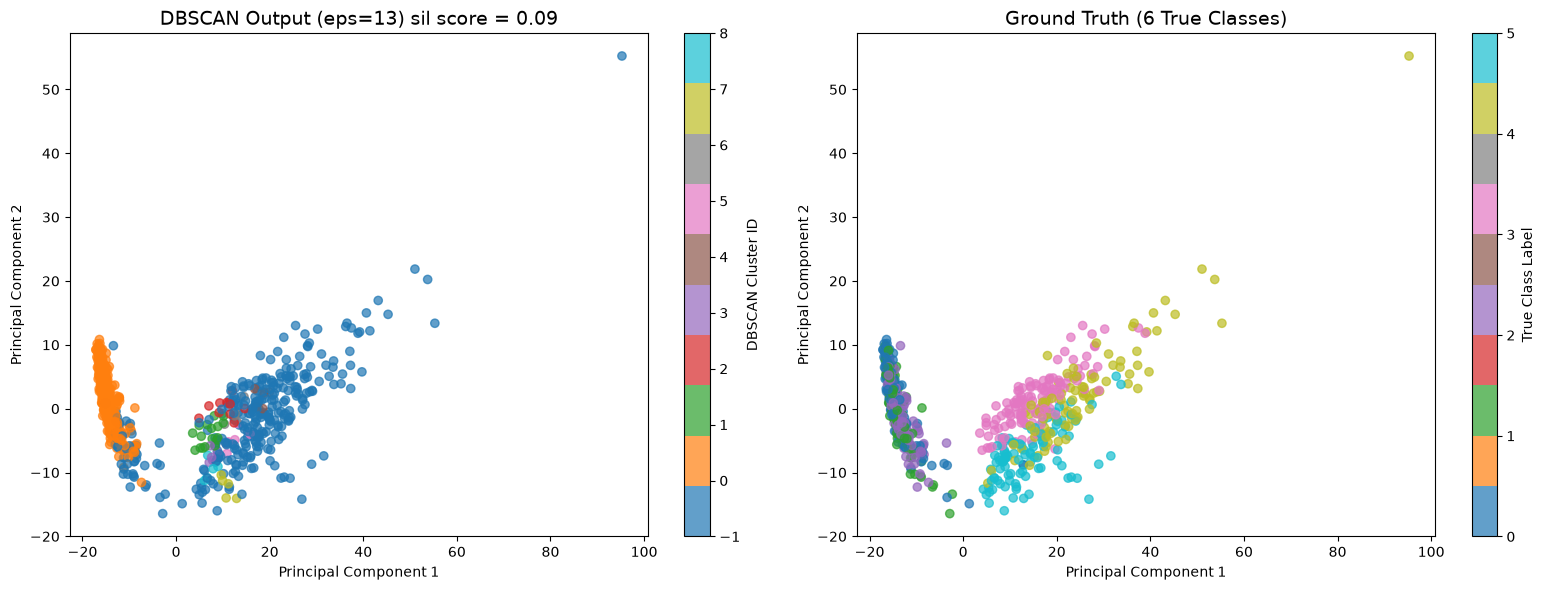

In [ ]:
db(n=13)

In [122]:
X_dev_scaled_pca.shape

(736, 100)

In [123]:
X_dev_scaled_toppca = X_dev_scaled_pca[:, 0:2]
X_train_scaled_toppca = X_train_scaled_pca[:, 0:2]
X_test_scaled_toppca = X_test_scaled_pca[:, 0:2]

In [124]:
X_dev_scaled_toppca.shape

(736, 2)

In [125]:
def km_toppca(numk = 6):
    kmeans = KMeans(n_clusters = numk)

    kmeans.fit(X_train_scaled_toppca)

    X_dev_pred = kmeans.predict(X_dev_scaled_toppca)

    sil_score = silhouette_score(X_dev_scaled_toppca, X_dev_pred)

    # Create a figure with 2 plots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: The 2 Unsupervised KMeans Clusters
    scatter1 = ax1.scatter(
        X_dev_scaled_pca[:, 0], 
        X_dev_scaled_pca[:, 1], 
        c=X_dev_pred, 
        cmap='tab10',       # Clean Blue/Red colormap for 2 clusters
        alpha=0.7
    )
    ax1.set_title(f'KMeans Output for top pca (n_clusters={numk}) sil_score = {sil_score:.2f}', fontsize=14)
    ax1.set_xlabel('Principal Component 1')
    ax1.set_ylabel('Principal Component 2')
    fig.colorbar(scatter1, ax=ax1, label='KMeans Cluster ID')

    y_dev_encoded = pd.Categorical(y_dev)

    # Plot 2: The 6 Original True Classes
    scatter2 = ax2.scatter(
        X_dev_scaled_pca[:, 0], 
        X_dev_scaled_pca[:, 1], 
        c=y_dev_encoded.codes,          # Your original 6 classes
        cmap='tab10',     # Categorical colormap great for up to 10 classes
        alpha=0.7
    )
    ax2.set_title('Ground Truth (6 True Classes)', fontsize=14)
    ax2.set_xlabel('Principal Component 1')
    ax2.set_ylabel('Principal Component 2')
    fig.colorbar(scatter2, ax=ax2, label='True Class Label')

    plt.tight_layout()
    plt.savefig(f"plots/top pca_k={numk}")
    plt.show()

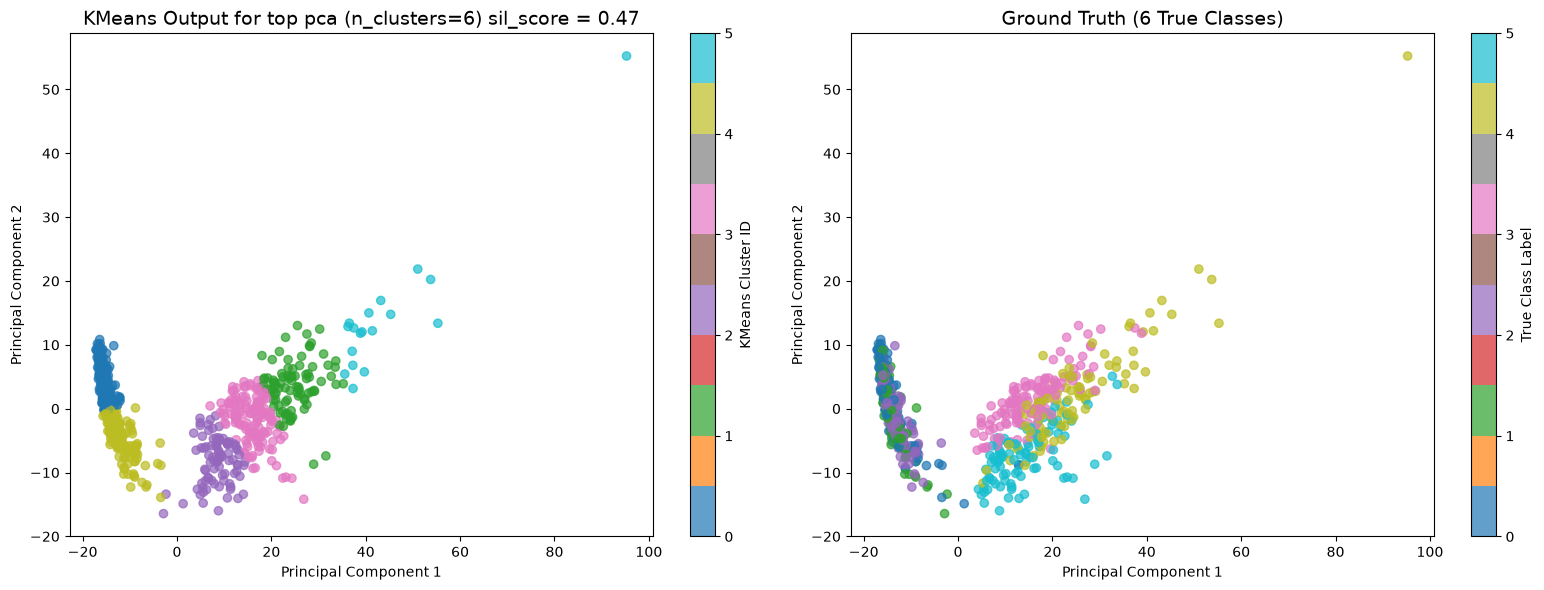

In [126]:
km_toppca()

In [134]:
def db_toppca(n = .1):
    db = DBSCAN(eps = n)

    X_dev_pred = db.fit_predict(X_dev_scaled_toppca)

    sil_score = silhouette_score(X_dev_scaled_pca, X_dev_pred)

    # Create a figure with 2 plots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: The 2 Unsupervised KMeans Clusters
    scatter1 = ax1.scatter(
        X_dev_scaled_pca[:, 0], 
        X_dev_scaled_pca[:, 1], 
        c=X_dev_pred, 
        cmap='tab10',       # Clean Blue/Red colormap for 2 clusters
        alpha=0.7
    )
    ax1.set_title(f'DBSCAN Output (eps={n}) sil score = {sil_score:.2f}', fontsize=14)
    ax1.set_xlabel('Principal Component 1')
    ax1.set_ylabel('Principal Component 2')
    fig.colorbar(scatter1, ax=ax1, label='DBSCAN Cluster ID')

    y_dev_encoded = pd.Categorical(y_dev)

    # Plot 2: The 6 Original True Classes
    scatter2 = ax2.scatter(
        X_dev_scaled_pca[:, 0], 
        X_dev_scaled_pca[:, 1], 
        c=y_dev_encoded.codes,          # Your original 6 classes
        cmap='tab10',     # Categorical colormap great for up to 10 classes
        alpha=0.7
    )
    ax2.set_title('Ground Truth (6 True Classes)', fontsize=14)
    ax2.set_xlabel('Principal Component 1')
    ax2.set_ylabel('Principal Component 2')
    fig.colorbar(scatter2, ax=ax2, label='True Class Label')

    plt.tight_layout()
    plt.savefig(f"plots/dbscan_toppca")
    plt.show()

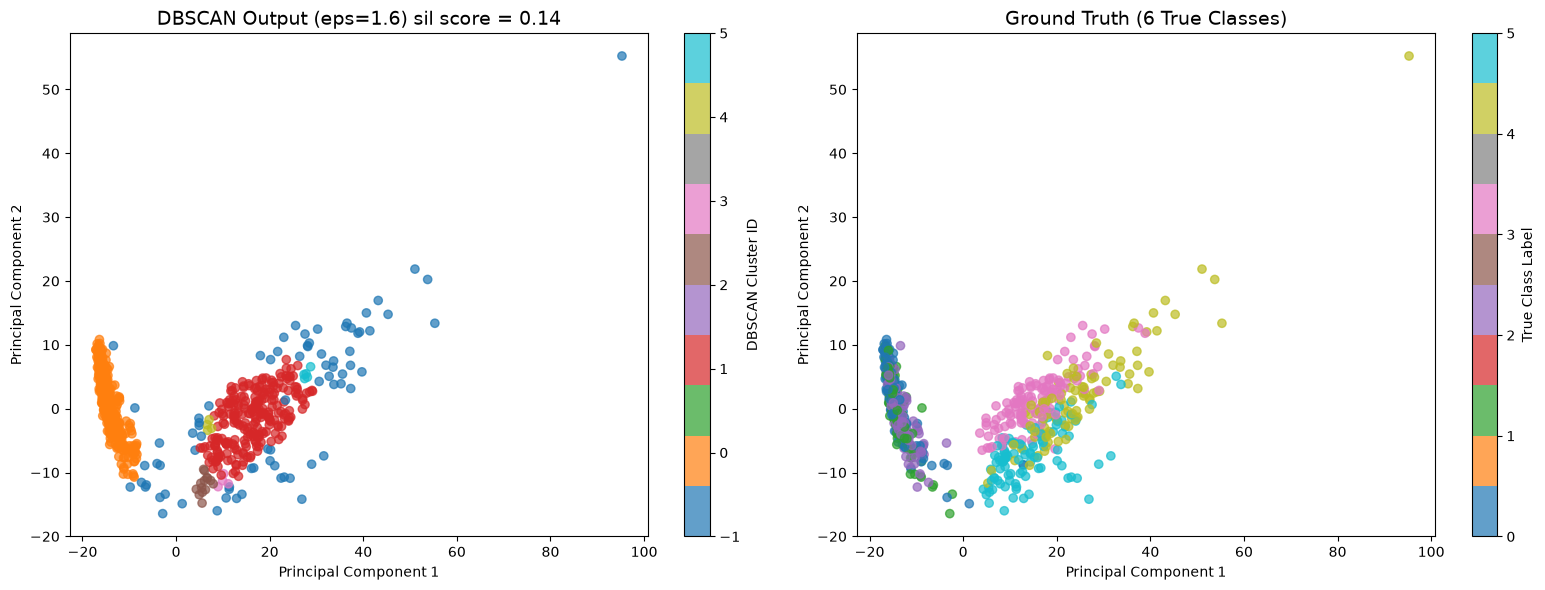

In [163]:
db_toppca(1.6)

In [165]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [166]:
rf.feature_importances_

array([2.82373037e-04, 2.91144273e-04, 1.72374849e-04, 1.21259174e-02,
       2.86713423e-04, 5.13377637e-04, 1.78817463e-03, 3.23397756e-04,
       7.33267383e-04, 6.46735394e-03, 2.62714740e-04, 2.22515403e-04,
       4.26174645e-04, 2.02931083e-04, 2.46668523e-04, 4.43132211e-04,
       1.68965843e-03, 5.56365306e-04, 2.84867792e-04, 1.39729031e-03,
       4.03114550e-04, 2.16266802e-04, 9.85558673e-04, 1.67098037e-04,
       3.06510606e-04, 9.37565402e-04, 2.09758572e-04, 1.90414574e-04,
       2.37357282e-04, 1.53468083e-04, 1.17073730e-04, 1.73933044e-04,
       2.53959467e-04, 2.14953897e-04, 9.08755734e-05, 2.03006731e-04,
       2.52778055e-04, 6.49230496e-03, 1.45507991e-03, 3.14441650e-03,
       1.69480068e-02, 3.04897530e-02, 7.23711781e-03, 1.26892746e-03,
       4.02388117e-04, 1.15252407e-03, 5.86342687e-04, 1.03599295e-03,
       8.66958771e-04, 2.36416217e-02, 2.34199670e-02, 9.27772942e-03,
       3.80644554e-02, 2.85146886e-02, 9.51730000e-03, 3.82285536e-03,
      